# Data Exploration (EDA)

This notebook provides an in-depth analysis of processed telemetry data to evaluate and compare teammate performance. Through comparative visualizations it's possiblet to identify key differences in driving styles such as braking points, gear shift patterns, throttle application, and overall speed profiles between two drivers from the same team.


##  Team and Grand Prix Selection

Define the target team, season, and Grand Prix session to be analyzed. This step sets the global variables required to ensure the subsequent pipeline is scoped precisely to the desired telemetry dataset, ensuring consistent and reproducible comparisons.


In [1]:
team = "McLaren"
grand_prix = "British Grand Prix"
year = 2025

## Setup and Dependencies

Import essential libraries, including fastf1 for data retrieval and plotting, alongside your custom local modules from the src directory. This section also configures the environment path to ensure seamless access to the project's utility functions, regardless of the notebook's location within the repository.


In [2]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *

## Load Processed Data

Initialize the fastf1 session and retrieve the relevant telemetry. This step involves filtering for the specific team, determining track segments and turn locations, and loading the cleaned, interpolated telemetry data from the cache. This ensures the data is ready for high-fidelity visualization and analysis.




In [3]:
session = fastf1.get_session(year, grand_prix, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, team)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(year, grand_prix, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {year} {grand_prix} {driver_1} and {driver_2} not found: {e}")

req         WARNING 	DEFAULT CACHE ENABLED! (50.15 MB) C:\Users\joseg\AppData\Local\Temp\fastf1
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '63', '44', '16', '12', '87', '14', '10', '55', '22', '6', '23', '31', '30', '5', '18', '27', '43']



Processed data for 2025 British Grand Prix PIA and NOR found in cache.
Driver 1: PIA, Driver 2: NOR, Segment: Q3


## Basic Data Inspection

Conduct a sanity check on the interpolated telemetry data. This includes reviewing data types, inspecting summary statistics (mean, standard deviation, quartiles) for each telemetry channel, and previewing the raw data structure. This validation step is crucial to ensure data quality before generating complex plots.

In [4]:
print(f"\n{lap_1['Driver']} interpolated telemetry data info:\n")
print(lap_1["Telemetry"].info())
print(f"\n{lap_2['Driver']} interpolated telemetry data info:\n")
print(lap_2["Telemetry"].info())

print(f"{lap_1['Driver']} interpolated telemetry description:\n\n {lap_1["Telemetry"].describe()}")
print(f"\n{lap_2['Driver']} interpolated telemetry description:\n\n {lap_2["Telemetry"].describe()}")

print(f"\n{lap_1['Driver']} interpolated telemetry head:\n\n {lap_1["Telemetry"].head()}")
print(f"\n{lap_2['Driver']} interpolated telemetry head:\n\n {lap_2["Telemetry"].head()}")


PIA interpolated telemetry data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  631 non-null    float64
 1   Speed     631 non-null    float64
 2   RPM       631 non-null    int64  
 3   Throttle  631 non-null    float64
 4   nGear     631 non-null    int64  
 5   Brake     631 non-null    int64  
 6   Time      631 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 34.6 KB
None

NOR interpolated telemetry data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  631 non-null    float64
 1   Speed     631 non-null    float64
 2   RPM       631 non-null    int64  
 3   Throttle  631 non-null    float64
 4   nGear     631 non-null    int64  
 5   Brake     631 non-null    i

## Variables' Comparison and Delta 

Perform a granular performance comparison across key telemetry variables: Speed, Throttle, Brake, Gear, RPM.

Comparison: Plots both drivers' data on the same axis to identify visual discrepancies in driving behavior.

Delta: Visualizes the direct difference between the two drivers, highlighting exactly where on the track one driver is gaining or losing time relative to their teammate.

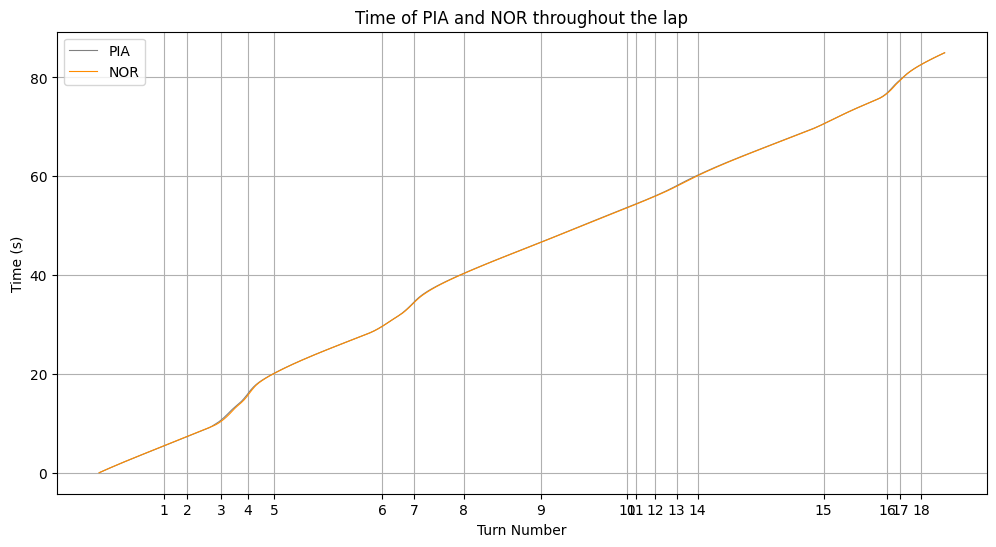

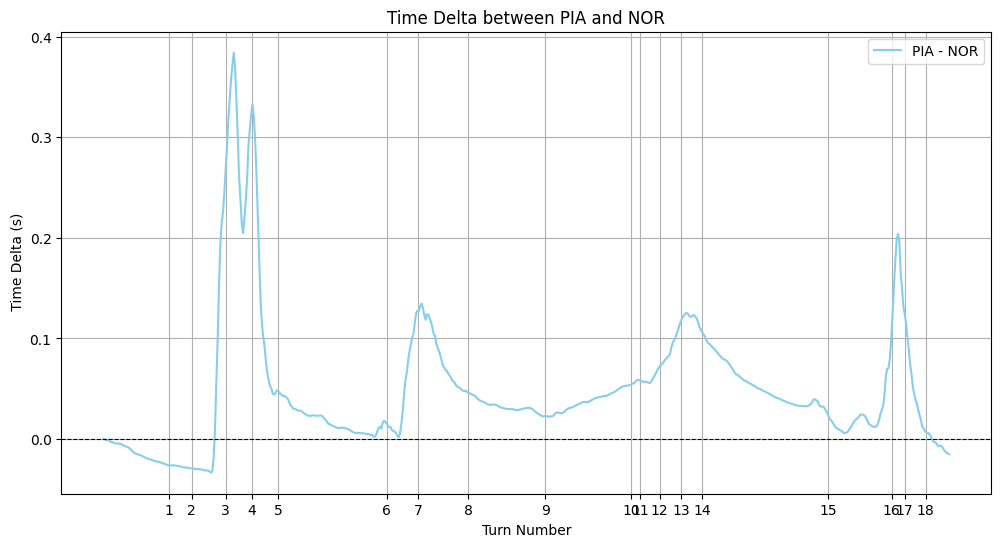

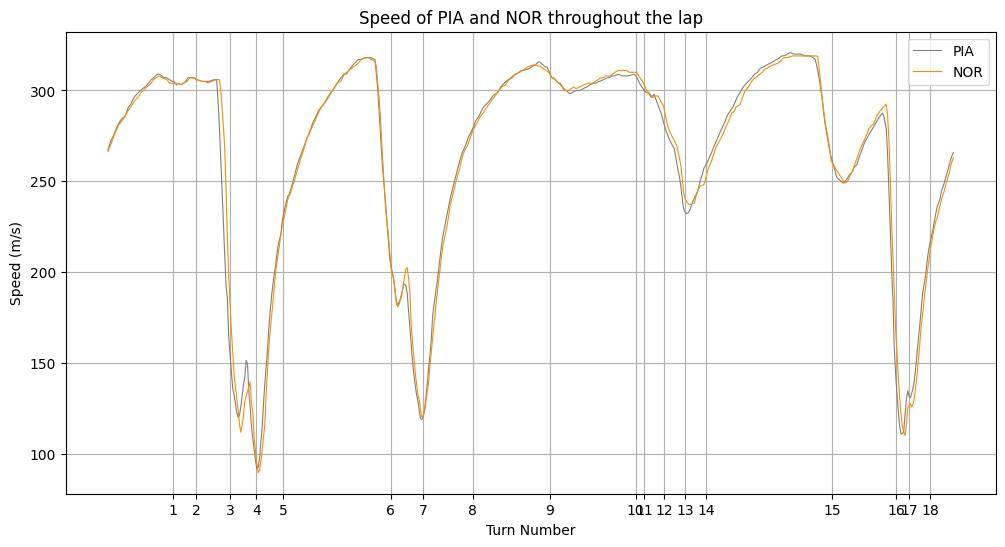

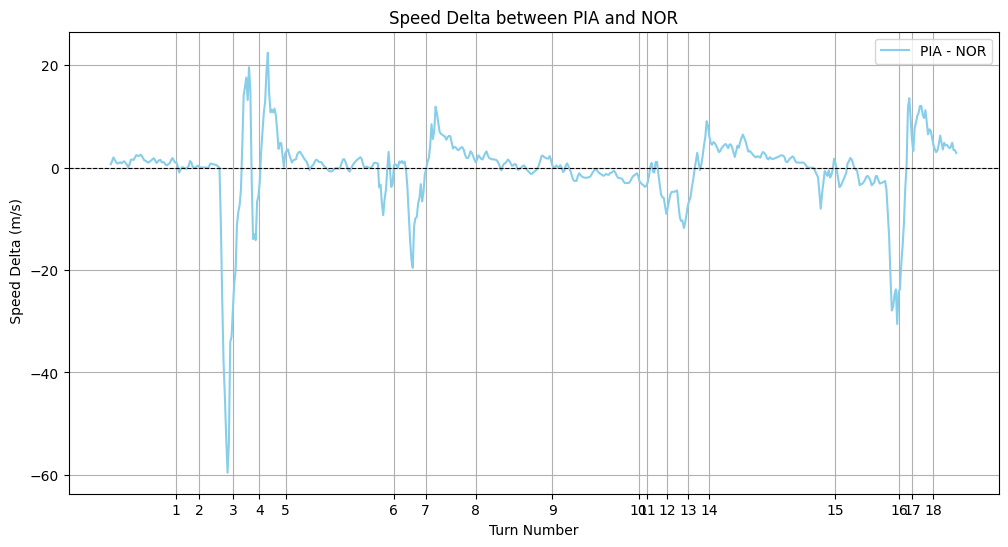

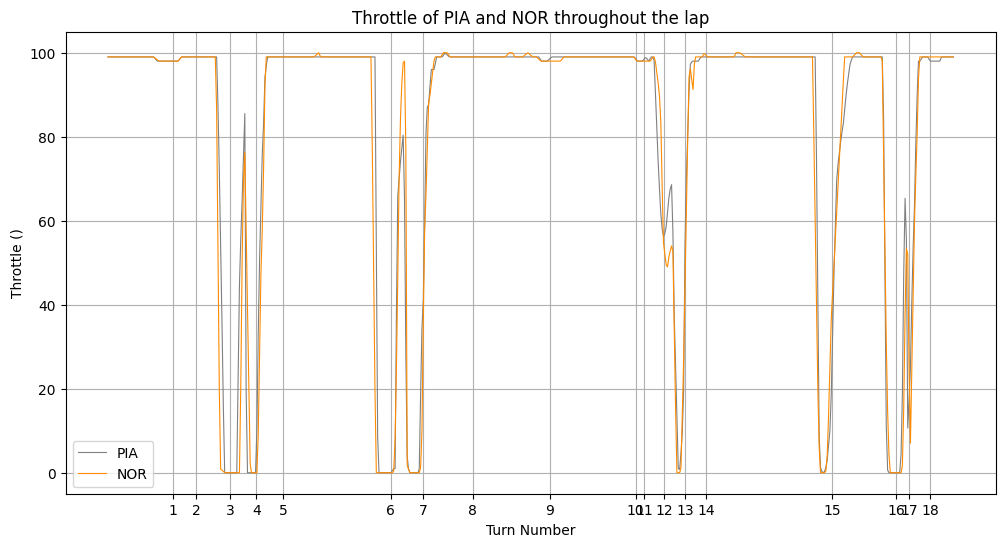

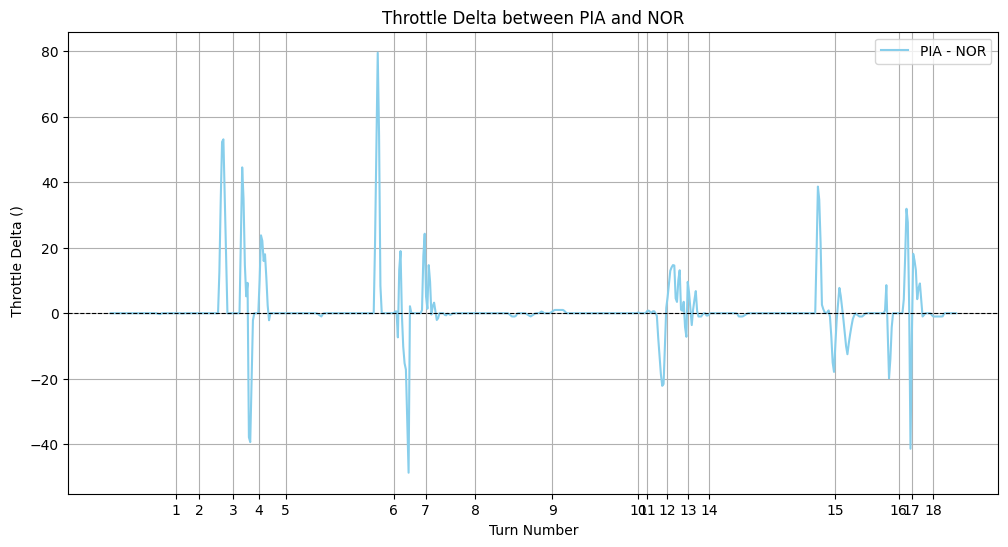

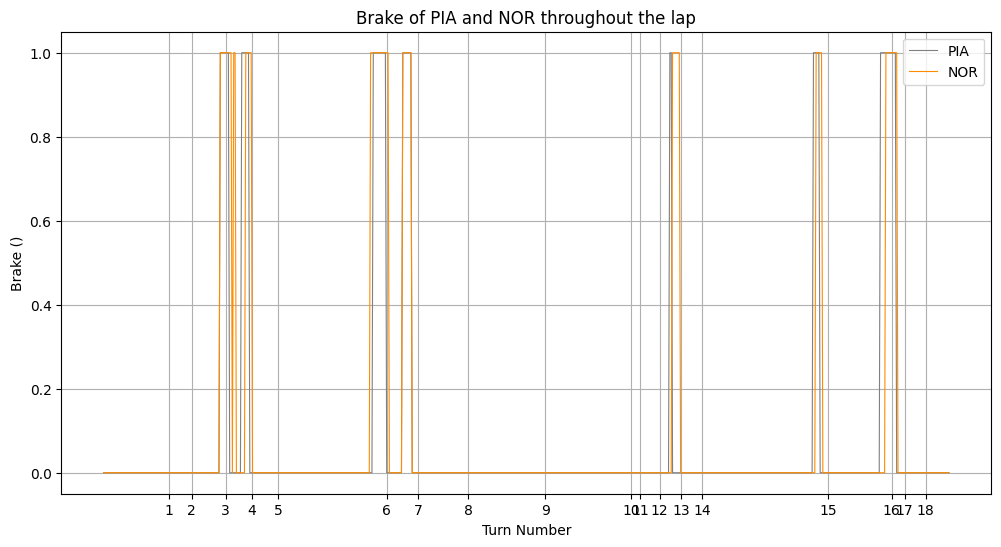

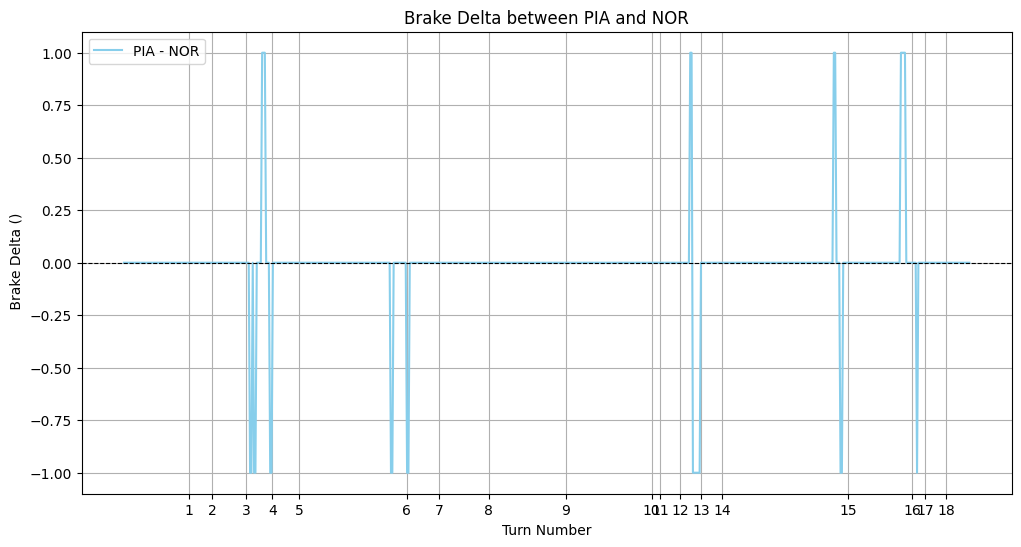

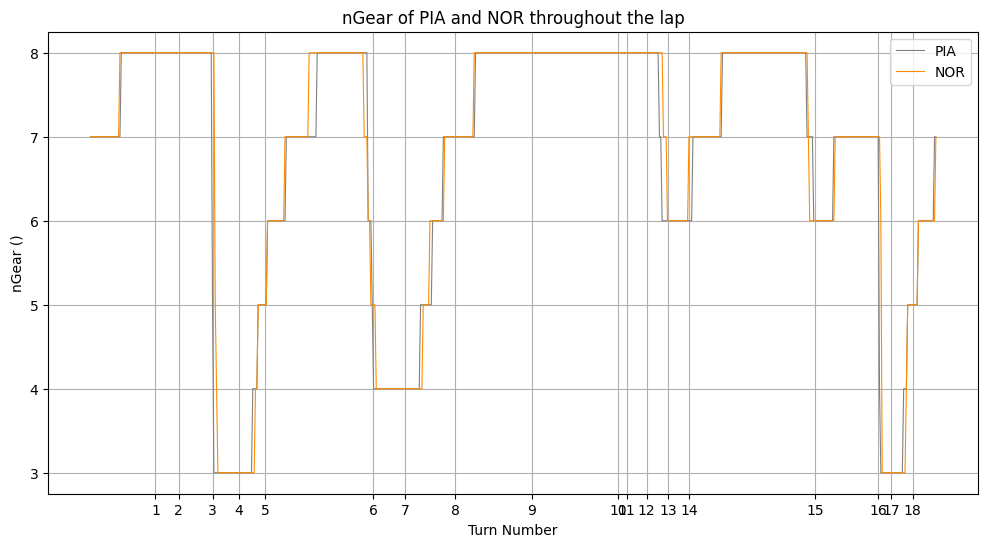

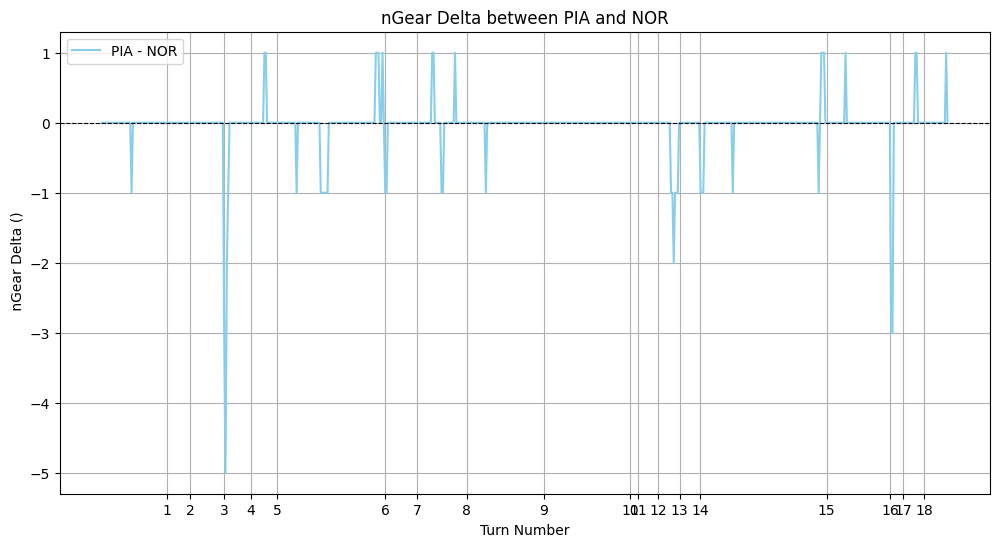

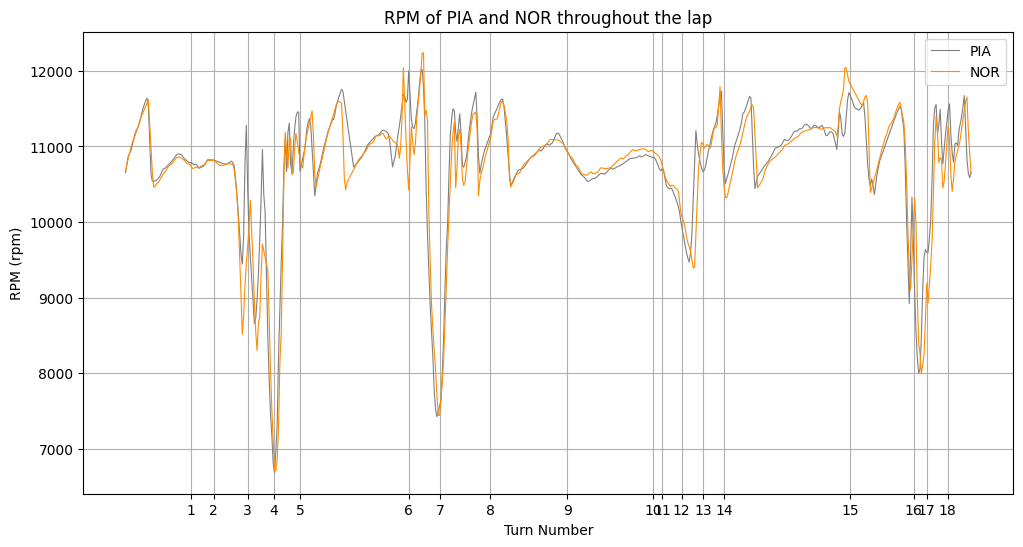

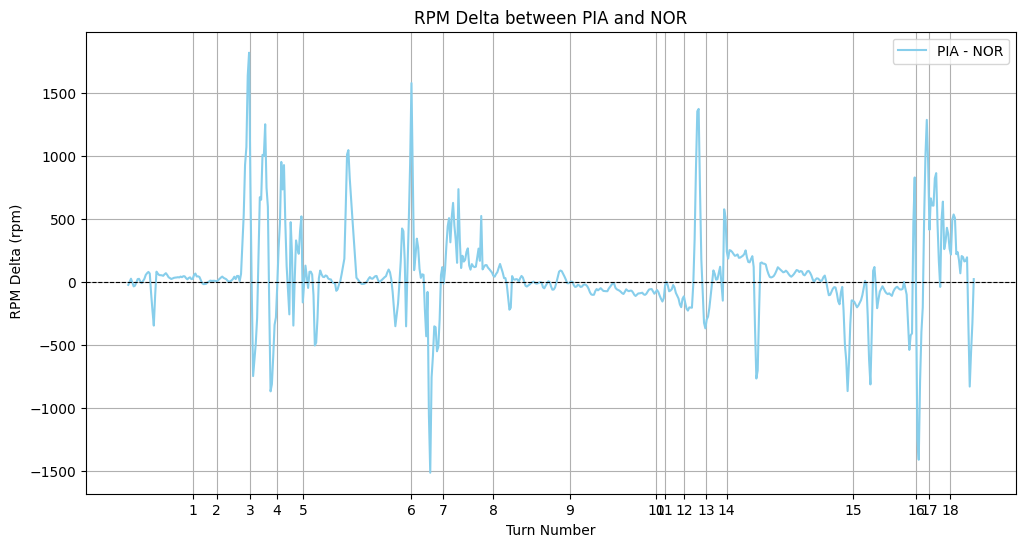

In [5]:
for variable, unit in [("Time", "s"), ("Speed", "m/s"), ("Throttle", ""), ("Brake", ""), ("nGear", ""), ("RPM", "rpm")]:
    fig = plot_variable_comparison(lap_1, lap_2, variable, turns, y_unit=unit)
    save_figure(fig, "telemetry", "comparison", f"{variable.lower()}", year, grand_prix, team, driver_1, driver_2)
    fig = plot_variable_delta(lap_1, lap_2, variable, turns, y_unit=unit)
    save_figure(fig, "telemetry", "delta", f"{variable.lower()}", year, grand_prix, team, driver_1, driver_2)